# POI Assignment Quality Validation

Examine the quality of tiered POI assignments and evaluate whether parameter settings need adjustment.

**Validation areas**:
1. Match rate by confidence tier
2. Distance distributions
3. POI category distributions
4. Spatial patterns (urban vs rural)
5. Multiple POI competition (how many POIs within each tier distance)
6. Assignment method effectiveness
7. Parameter sensitivity analysis

**Parameters to validate**:
- Tier 2: 20m (high confidence)
- Tier 3: 50m (medium confidence)
- Tier 4: 100m (low confidence)

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree

sns.set_style('whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline

## 1. Load Data

In [2]:
# Paths
ROOT_DIR = Path('../')
ASSIGNMENT_DIR = ROOT_DIR / 'dbs' / 'poi_assignment'
POI_DIR = ROOT_DIR / "dbs" / "poi_se" / "POI_se_2026_03_05"

In [3]:

# Load assignment results
df_assigned = pd.read_parquet(ASSIGNMENT_DIR / 'stops_poi_assigned.parquet')

print(f"Loaded {len(df_assigned):,} stop assignments")
print(f"\nColumns: {df_assigned.columns.tolist()}")
print(f"\nFirst few rows:")
display(df_assigned.head())

Loaded 175,487,188 stop assignments

Columns: ['stop_id', 'device_aid', 'poi_id', 'poi_distance', 'confidence_tier', 'poi_category', 'poi_subcategory', 'assignment_method']

First few rows:


,stop_id,device_aid,poi_id,poi_distance,confidence_tier,poi_category,poi_subcategory,assignment_method
0,1,024f7ea9-47fc-4975-9d88-1f9105dd3e61,zzy-228@ayt-6g3-d9z,42.40,3,Elementary and Secondary Schools,Elementary and Secondary Schools,distance
1,2,0265d6fc-68fd-4246-910a-fd552f19c968,NaN,NaN,0,NaN,NaN,NaN
2,3,030d1a35-f85d-443d-b6b5-1d3ad1b5c1ed,NaN,NaN,0,NaN,NaN,NaN
3,4,0371c573-ed33-4ebe-b9e0-279627e14357,zzy-23t@ayt-gkd-jsq,19.78,1,Restaurants and Other Eating Places,Full-Service Restaurants,footprint
4,5,03af1e95-2195-4910-844d-35970785c8fc,zzy-222@ayy-qnf-tjv,24.54,3,General Freight Trucking,"General Freight Trucking, Long-Distance, Truck...",distance


In [4]:
# Load POI data for reference
df_poi = pd.read_parquet(POI_DIR)
print(f"Loaded {len(df_poi):,} POIs")

Loaded 658,731 POIs


## 2. Overall Match Statistics

In [5]:
# Match rate by tier
print("="*60)
print("OVERALL MATCH STATISTICS")
print("="*60)

total = len(df_assigned)
matched = (df_assigned['confidence_tier'] > 0).sum()
unmatched = (df_assigned['confidence_tier'] == 0).sum()

print(f"\nTotal stops: {total:,}")
print(f"Matched: {matched:,} ({matched/total*100:.1f}%)")
print(f"Unmatched: {unmatched:,} ({unmatched/total*100:.1f}%)")

print(f"\nBreakdown by tier:")
tier_counts = df_assigned['confidence_tier'].value_counts().sort_index()
for tier, count in tier_counts.items():
    if tier == 0:
        print(f"  Tier 0 (unmatched): {count:,} ({count/total*100:.1f}%)")
    elif tier == 1:
        print(f"  Tier 1 (footprint): {count:,} ({count/total*100:.1f}%)")
    elif tier == 2:
        print(f"  Tier 2 (0-20m): {count:,} ({count/total*100:.1f}%)")
    elif tier == 3:
        print(f"  Tier 3 (20-50m): {count:,} ({count/total*100:.1f}%)")
    elif tier == 4:
        print(f"  Tier 4 (50-100m): {count:,} ({count/total*100:.1f}%)")

OVERALL MATCH STATISTICS

Total stops: 175,487,188
Matched: 80,820,135 (46.1%)
Unmatched: 94,667,053 (53.9%)

Breakdown by tier:
  Tier 0 (unmatched): 94,667,053 (53.9%)
  Tier 1 (footprint): 24,977,212 (14.2%)
  Tier 2 (0-20m): 11,814,664 (6.7%)
  Tier 3 (20-50m): 24,143,861 (13.8%)
  Tier 4 (50-100m): 19,884,398 (11.3%)


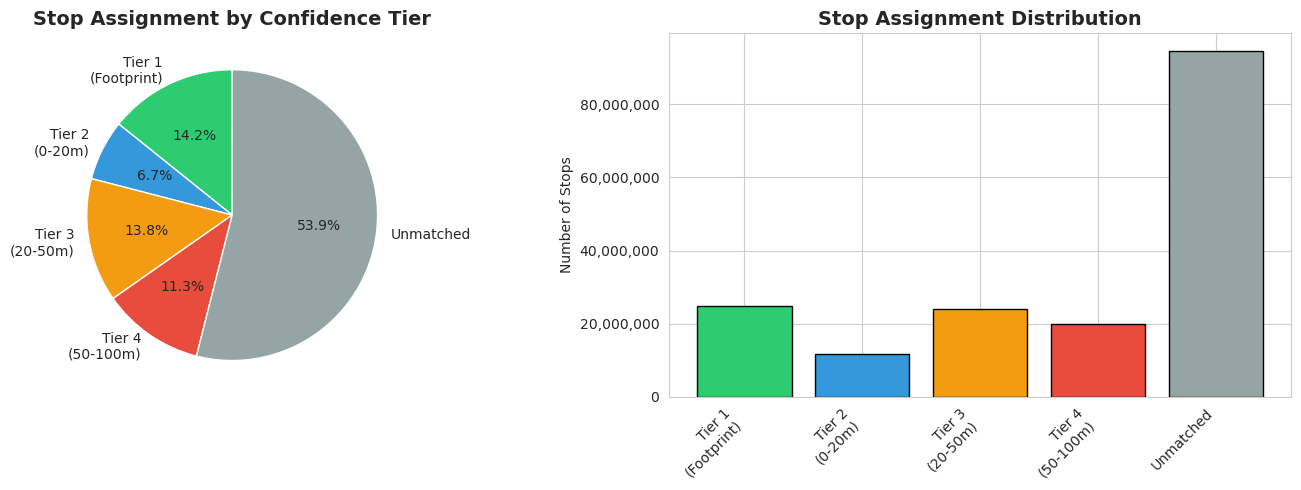

In [6]:
# Visualize match rate by tier
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
tier_labels = ['Tier 1\n(Footprint)', 'Tier 2\n(0-20m)', 'Tier 3\n(20-50m)', 
               'Tier 4\n(50-100m)', 'Unmatched']
tier_values = [
    (df_assigned['confidence_tier'] == 1).sum(),
    (df_assigned['confidence_tier'] == 2).sum(),
    (df_assigned['confidence_tier'] == 3).sum(),
    (df_assigned['confidence_tier'] == 4).sum(),
    (df_assigned['confidence_tier'] == 0).sum()
]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
ax1.pie(tier_values, labels=tier_labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Stop Assignment by Confidence Tier', fontsize=14, fontweight='bold')

# Bar chart
ax2.bar(range(len(tier_labels)), tier_values, color=colors, edgecolor='black')
ax2.set_xticks(range(len(tier_labels)))
ax2.set_xticklabels(tier_labels, rotation=45, ha='right')
ax2.set_ylabel('Number of Stops')
ax2.set_title('Stop Assignment Distribution', fontsize=14, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 3. Distance Distribution Analysis

In [7]:
# Distance statistics by tier (using aggregation, not full copy)
print("\nDistance Statistics by Tier:")
print("="*60)

for tier in [1, 2, 3, 4]:
    tier_mask = df_assigned['confidence_tier'] == tier
    tier_distances = df_assigned.loc[tier_mask, 'poi_distance']
    
    if len(tier_distances) > 0:
        print(f"\nTier {tier}:")
        print(f"  Count: {len(tier_distances):,}")
        print(f"  Mean: {tier_distances.mean():.2f}m")
        print(f"  Median: {tier_distances.median():.2f}m")
        print(f"  Std: {tier_distances.std():.2f}m")
        print(f"  Min: {tier_distances.min():.2f}m")
        print(f"  Max: {tier_distances.max():.2f}m")
        print(f"  25th percentile: {tier_distances.quantile(0.25):.2f}m")
        print(f"  75th percentile: {tier_distances.quantile(0.75):.2f}m")


Distance Statistics by Tier:

Tier 1:
  Count: 24,977,212
  Mean: 52.72m
  Median: 19.63m
  Std: 161.99m
  Min: 0.00m
  Max: 3837.95m
  25th percentile: 9.90m
  75th percentile: 43.39m

Tier 2:
  Count: 11,814,664
  Mean: 13.27m
  Median: 13.65m
  Std: 4.27m
  Min: 0.01m
  Max: 20.00m
  25th percentile: 10.13m
  75th percentile: 16.84m

Tier 3:
  Count: 24,143,861
  Mean: 33.84m
  Median: 33.32m
  Std: 8.59m
  Min: 20.00m
  Max: 50.00m
  25th percentile: 26.31m
  75th percentile: 41.06m

Tier 4:
  Count: 19,884,398
  Mean: 70.90m
  Median: 69.11m
  Std: 14.00m
  Min: 50.00m
  Max: 100.00m
  25th percentile: 58.72m
  75th percentile: 81.88m


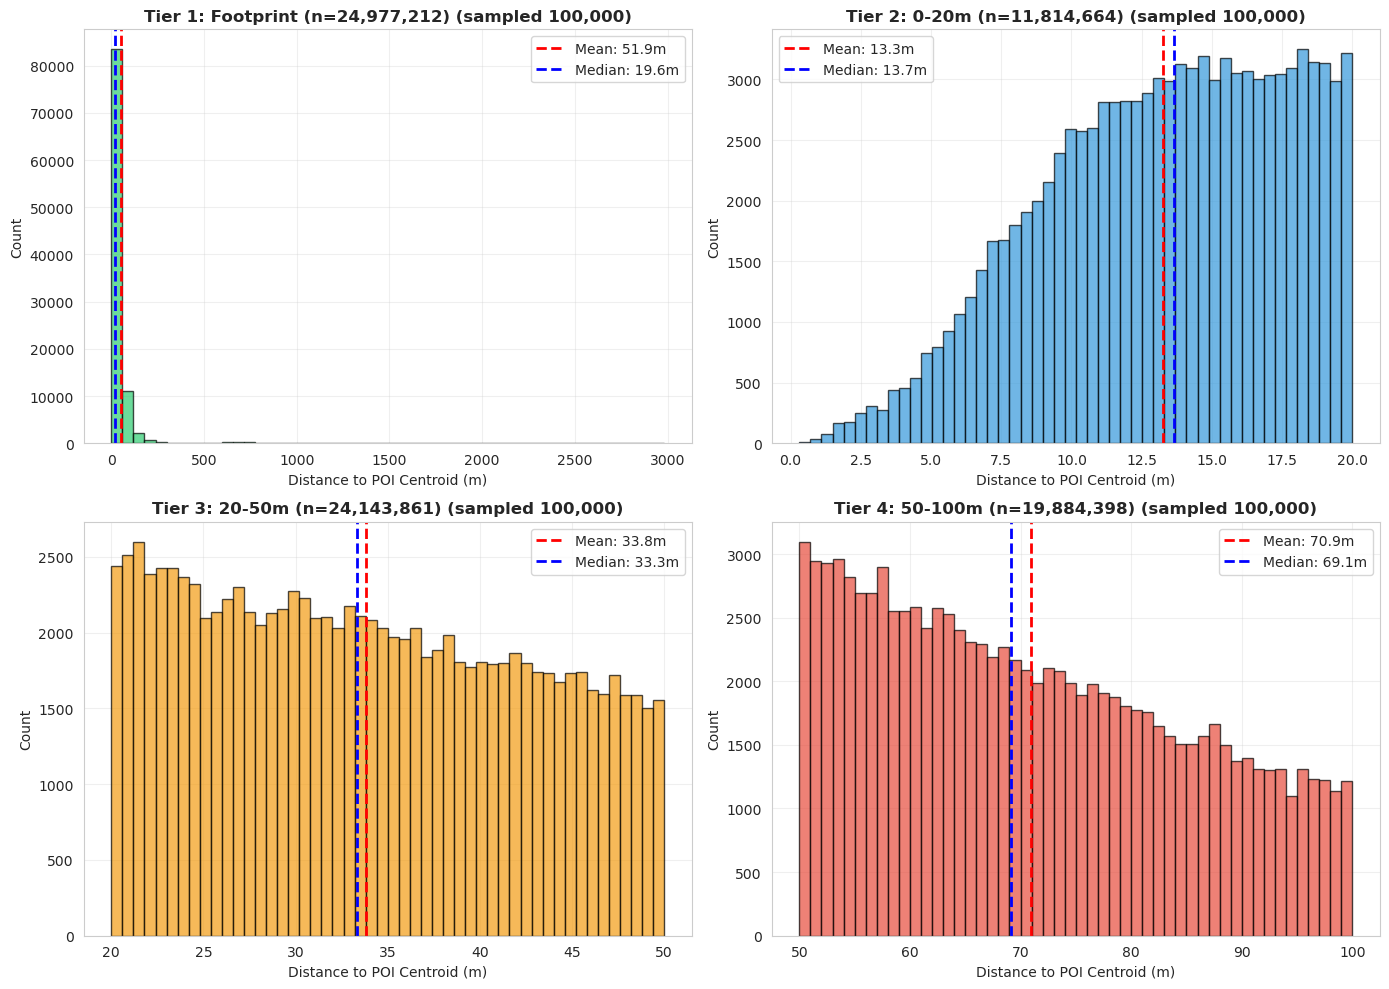

In [8]:
# Visualize distance distributions (sampled for memory efficiency)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

SAMPLE_SIZE = 100_000  # Sample for visualization

for i, tier in enumerate([1, 2, 3, 4]):
    tier_mask = df_assigned['confidence_tier'] == tier
    tier_count = tier_mask.sum()
    
    if tier_count > 0:
        ax = axes[i]
        
        # Sample for visualization if too large
        if tier_count > SAMPLE_SIZE:
            tier_data = df_assigned.loc[tier_mask, 'poi_distance'].sample(n=SAMPLE_SIZE, random_state=42)
            sample_note = f" (sampled {SAMPLE_SIZE:,})"
        else:
            tier_data = df_assigned.loc[tier_mask, 'poi_distance']
            sample_note = ""
        
        ax.hist(tier_data, bins=50, color=colors[i], edgecolor='black', alpha=0.7)
        ax.axvline(tier_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {tier_data.mean():.1f}m')
        ax.axvline(tier_data.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {tier_data.median():.1f}m')
        
        if tier == 1:
            ax.set_title(f'Tier 1: Footprint (n={tier_count:,}){sample_note}', fontweight='bold')
        elif tier == 2:
            ax.set_title(f'Tier 2: 0-20m (n={tier_count:,}){sample_note}', fontweight='bold')
        elif tier == 3:
            ax.set_title(f'Tier 3: 20-50m (n={tier_count:,}){sample_note}', fontweight='bold')
        elif tier == 4:
            ax.set_title(f'Tier 4: 50-100m (n={tier_count:,}){sample_note}', fontweight='bold')
        
        ax.set_xlabel('Distance to POI Centroid (m)')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. POI Category Analysis

In [9]:
# Top categories by tier (memory efficient)
print("\nTop 10 POI Categories by Tier:")
print("="*60)

for tier in [1, 2, 3, 4]:
    tier_mask = df_assigned['confidence_tier'] == tier
    tier_count = tier_mask.sum()
    
    if tier_count > 0:
        print(f"\nTier {tier} (n={tier_count:,}):")
        cat_counts = df_assigned.loc[tier_mask, 'poi_category'].value_counts().head(10)
        for cat, count in cat_counts.items():
            print(f"  {cat}: {count:,} ({count/tier_count*100:.1f}%)")


Top 10 POI Categories by Tier:

Tier 1 (n=24,977,212):
  Elementary and Secondary Schools: 2,426,729 (9.7%)
  Restaurants and Other Eating Places: 1,989,281 (8.0%)
  Other Amusement and Recreation Industries: 1,175,464 (4.7%)
  Personal Care Services: 982,165 (3.9%)
  Activities Related to Real Estate: 818,666 (3.3%)
  Offices of Physicians: 791,493 (3.2%)
  Services to Buildings and Dwellings: 626,309 (2.5%)
  Grocery Stores: 618,156 (2.5%)
  Child Day Care Services: 599,350 (2.4%)
  Other Personal Services: 589,619 (2.4%)

Tier 2 (n=11,814,664):
  Restaurants and Other Eating Places: 1,238,695 (10.5%)
  Personal Care Services: 805,476 (6.8%)
  Activities Related to Real Estate: 620,853 (5.3%)
  Urban Transit Systems: 534,894 (4.5%)
  Services to Buildings and Dwellings: 368,096 (3.1%)
  Elementary and Secondary Schools: 363,191 (3.1%)
  Other Schools and Instruction: 354,816 (3.0%)
  Printing and Related Support Activities: 305,714 (2.6%)
  Other Amusement and Recreation Industries:

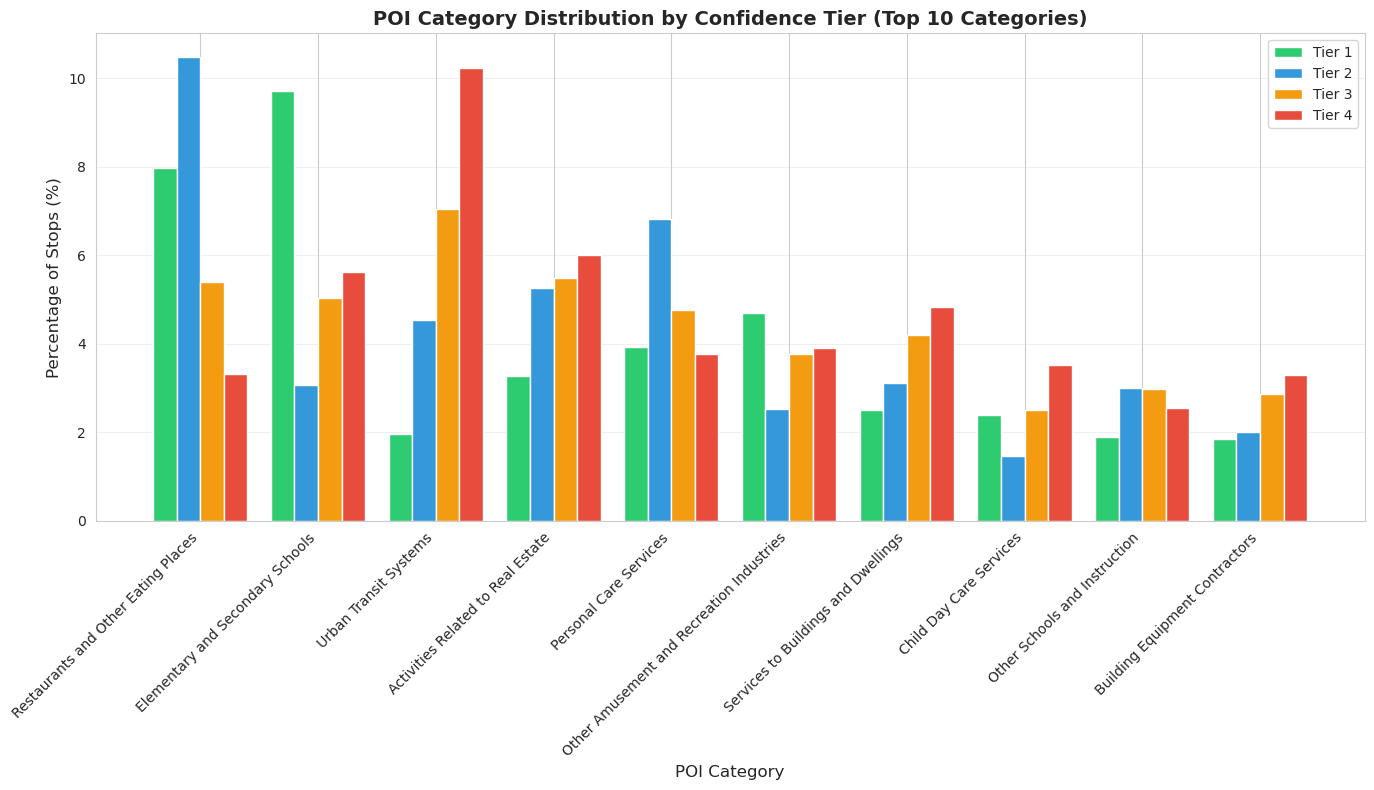

In [10]:
# Compare category distributions across tiers (memory efficient)
matched_mask = df_assigned['confidence_tier'] > 0
top_categories = df_assigned.loc[matched_mask, 'poi_category'].value_counts().head(10).index

fig, ax = plt.subplots(figsize=(14, 8))

tier_cat_data = []
for tier in [1, 2, 3, 4]:
    tier_mask = df_assigned['confidence_tier'] == tier
    tier_count = tier_mask.sum()
    if tier_count > 0:
        cat_pcts = df_assigned.loc[tier_mask, 'poi_category'].value_counts(normalize=True).reindex(top_categories, fill_value=0) * 100
        tier_cat_data.append(cat_pcts.values)
    else:
        tier_cat_data.append(np.zeros(len(top_categories)))

x = np.arange(len(top_categories))
width = 0.2

for i, tier in enumerate([1, 2, 3, 4]):
    ax.bar(x + i*width, tier_cat_data[i], width, label=f'Tier {tier}', color=colors[i])

ax.set_xlabel('POI Category', fontsize=12)
ax.set_ylabel('Percentage of Stops (%)', fontsize=12)
ax.set_title('POI Category Distribution by Confidence Tier (Top 10 Categories)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(top_categories, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Assignment Method Effectiveness

In [11]:
# Compare footprint vs distance methods (memory efficient)
print("\nAssignment Method Statistics:")
print("="*60)

matched_mask = df_assigned['confidence_tier'] > 0
total_matched = matched_mask.sum()

method_counts = df_assigned.loc[matched_mask, 'assignment_method'].value_counts()
for method, count in method_counts.items():
    print(f"\n{method.capitalize() if method else 'Unknown'}:")
    print(f"  Count: {count:,} ({count/total_matched*100:.1f}%)")
    
    method_mask = matched_mask & (df_assigned['assignment_method'] == method)
    method_distances = df_assigned.loc[method_mask, 'poi_distance']
    print(f"  Mean distance: {method_distances.mean():.2f}m")
    print(f"  Median distance: {method_distances.median():.2f}m")


Assignment Method Statistics:

Distance:
  Count: 55,842,923 (69.1%)
  Mean distance: 42.68m
  Median distance: 38.32m

Footprint:
  Count: 24,977,212 (30.9%)
  Mean distance: 52.72m
  Median distance: 19.63m


## 6. POI Competition Analysis

**Critical validation**: How many POIs are within each tier distance?  
If there are many POIs within the same tier distance, nearest-neighbor assignment may be unreliable.

In [12]:
# POI Competition Analysis (sampled for memory efficiency)
# Note: This analysis would require stop coordinates which aren't in the output

print("POI Competition Analysis:")
print("="*60)
print("\nNote: Detailed competition analysis requires original stop coordinates.")
print("Current analysis shows tier-based assignment quality.")

# Instead, show the ratio of matched POIs to total POIs
unique_pois_matched = df_assigned.loc[df_assigned['confidence_tier'] > 0, 'poi_id'].nunique()
total_pois = len(df_poi)

print(f"\nPOI Coverage:")
print(f"  Total POIs in dataset: {total_pois:,}")
print(f"  Unique POIs with at least 1 visit: {unique_pois_matched:,}")
print(f"  POI match rate: {unique_pois_matched/total_pois*100:.1f}%")

# Visits per POI distribution
poi_visit_counts = df_assigned.loc[df_assigned['confidence_tier'] > 0, 'poi_id'].value_counts()
print(f"\nVisits per POI (matched POIs):")
print(f"  Mean: {poi_visit_counts.mean():.1f}")
print(f"  Median: {poi_visit_counts.median():.1f}")
print(f"  Min: {poi_visit_counts.min()}")
print(f"  Max: {poi_visit_counts.max():,}")
print(f"  POIs with ≥50 visits: {(poi_visit_counts >= 50).sum():,}")
print(f"  POIs with ≥100 visits: {(poi_visit_counts >= 100).sum():,}")

POI Competition Analysis:

Note: Detailed competition analysis requires original stop coordinates.
Current analysis shows tier-based assignment quality.

POI Coverage:
  Total POIs in dataset: 658,731
  Unique POIs with at least 1 visit: 514,764
  POI match rate: 78.1%

Visits per POI (matched POIs):
  Mean: 157.0
  Median: 30.0
  Min: 1
  Max: 105,849
  POIs with ≥50 visits: 207,795
  POIs with ≥100 visits: 142,108


## 7. Spatial Patterns (if city data available)

In [13]:
# Analyze by city using SAMPLED data (memory efficient)
# Full merge of 80M rows would crash - use sampling instead

CITY_SAMPLE_SIZE = 500_000  # Sample for city analysis

print("\nMatch rates by city (sampled analysis):")
print("="*60)

# Sample matched stops only
matched_mask = df_assigned['confidence_tier'] > 0
n_matched = matched_mask.sum()

if n_matched > CITY_SAMPLE_SIZE:
    sample_idx = df_assigned[matched_mask].sample(n=CITY_SAMPLE_SIZE, random_state=42).index
    sample_df = df_assigned.loc[sample_idx, ['poi_id', 'confidence_tier', 'poi_distance']].copy()
    print(f"Using {CITY_SAMPLE_SIZE:,} sampled stops (from {n_matched:,} matched)")
else:
    sample_df = df_assigned.loc[matched_mask, ['poi_id', 'confidence_tier', 'poi_distance']].copy()

# Merge with POI city data
poi_cities = df_poi[['PLACEKEY', 'CITY']].rename(columns={'PLACEKEY': 'poi_id'})
sample_with_city = sample_df.merge(poi_cities, on='poi_id', how='left')

# Focus cities
focus_cities = ['Stockholm', 'Göteborg', 'Malmö']

for city in focus_cities:
    city_mask = sample_with_city['CITY'].str.contains(city, case=False, na=False)
    city_stops = sample_with_city[city_mask]
    
    if len(city_stops) > 0:
        print(f"\n{city}:")
        print(f"  Sampled stops: {len(city_stops):,}")
        tier_dist = city_stops['confidence_tier'].value_counts(normalize=True).sort_index() * 100
        for tier, pct in tier_dist.items():
            print(f"    Tier {tier}: {pct:.1f}%")
        print(f"  Mean distance: {city_stops['poi_distance'].mean():.2f}m")

# Clean up
del sample_df, sample_with_city
import gc
gc.collect()


Match rates by city (sampled analysis):
Using 500,000 sampled stops (from 80,820,135 matched)

Stockholm:
  Sampled stops: 47,866
    Tier 1: 44.0%
    Tier 2: 29.2%
    Tier 3: 20.9%
    Tier 4: 5.9%
  Mean distance: 40.49m

Göteborg:
  Sampled stops: 23,111
    Tier 1: 34.6%
    Tier 2: 19.7%
    Tier 3: 29.9%
    Tier 4: 15.8%
  Mean distance: 39.35m

Malmö:
  Sampled stops: 17,652
    Tier 1: 37.2%
    Tier 2: 17.4%
    Tier 3: 29.0%
    Tier 4: 16.4%
  Mean distance: 36.64m


8

## 8. Quality Flags and Recommendations

In [14]:
print("="*60)
print("QUALITY ASSESSMENT AND RECOMMENDATIONS")
print("="*60)

# Calculate key metrics (memory efficient - no copies)
total_stops = len(df_assigned)
total_matched = (df_assigned['confidence_tier'] > 0).sum()
match_rate = total_matched / total_stops * 100

tier1_pct = (df_assigned['confidence_tier'] == 1).sum() / total_matched * 100 if total_matched > 0 else 0
tier2_pct = (df_assigned['confidence_tier'] == 2).sum() / total_matched * 100 if total_matched > 0 else 0
tier3_pct = (df_assigned['confidence_tier'] == 3).sum() / total_matched * 100 if total_matched > 0 else 0
tier4_pct = (df_assigned['confidence_tier'] == 4).sum() / total_matched * 100 if total_matched > 0 else 0

high_confidence = tier1_pct + tier2_pct

print(f"\n1. Overall Match Rate: {match_rate:.1f}%")
if match_rate < 50:
    print("   ⚠️  WARNING: Low match rate (<50%)")
    print("   → Consider: Increasing Tier 4 radius or checking data quality")
elif match_rate > 90:
    print("   ⚠️  WARNING: Very high match rate (>90%)")
    print("   → May include spurious matches - review distance thresholds")
else:
    print("   ✓ Acceptable match rate")

print(f"\n2. High Confidence Assignments (Tier 1+2): {high_confidence:.1f}%")
if high_confidence < 40:
    print("   ⚠️  WARNING: Low high-confidence rate (<40%)")
    print("   → Consider: Building footprint coverage or Tier 2 radius")
else:
    print("   ✓ Good high-confidence coverage")

print(f"\n3. Tier 4 Usage (50-100m): {tier4_pct:.1f}%")
if tier4_pct > 30:
    print("   ⚠️  WARNING: High Tier 4 usage (>30%)")
    print("   → Consider: Excluding Tier 4 from main analysis (low confidence)")
else:
    print("   ✓ Tier 4 usage acceptable")

if total_matched > 0:
    matched_mask = df_assigned['confidence_tier'] > 0
    mean_dist = df_assigned.loc[matched_mask, 'poi_distance'].mean()
    print(f"\n4. Mean Assignment Distance: {mean_dist:.1f}m")
    if mean_dist > 50:
        print("   ⚠️  WARNING: High mean distance (>50m)")
        print("   → Review: May indicate POI data gaps or inappropriate matches")
    else:
        print("   ✓ Mean distance acceptable")

print("\n" + "="*60)
print("RECOMMENDATIONS FOR ANALYSIS")
print("="*60)

print("\n1. Primary Analysis:")
print("   → Use Tier 1 + 2 (high confidence) for main results")
print(f"   → n = {(df_assigned['confidence_tier'].isin([1, 2])).sum():,} stops")

print("\n2. Sensitivity Analysis:")
print("   → Compare results with/without Tier 3")
print(f"   → Tier 1+2+3: n = {(df_assigned['confidence_tier'].isin([1, 2, 3])).sum():,}")

print("\n3. Exclude from Analysis:")
print("   → Tier 4 (too uncertain for visitor diversity)")
print(f"   → Saves {tier4_pct:.1f}% of matches from potential errors")

print("\n4. Next Steps:")
print("   → Aggregate to tract-to-POI flows using IPW weights")
print("   → Filter POIs by minimum visit threshold (e.g., ≥50 visits)")
print("   → Calculate visitor diversity using Tier 1+2 assignments")

QUALITY ASSESSMENT AND RECOMMENDATIONS

1. Overall Match Rate: 46.1%
   ⚠️  WARNING: Low match rate (<50%)
   → Consider: Increasing Tier 4 radius or checking data quality

2. High Confidence Assignments (Tier 1+2): 45.5%
   ✓ Good high-confidence coverage

3. Tier 4 Usage (50-100m): 24.6%
   ✓ Tier 4 usage acceptable

4. Mean Assignment Distance: 45.8m
   ✓ Mean distance acceptable

RECOMMENDATIONS FOR ANALYSIS

1. Primary Analysis:
   → Use Tier 1 + 2 (high confidence) for main results
   → n = 36,791,876 stops

2. Sensitivity Analysis:
   → Compare results with/without Tier 3
   → Tier 1+2+3: n = 60,935,737

3. Exclude from Analysis:
   → Tier 4 (too uncertain for visitor diversity)
   → Saves 24.6% of matches from potential errors

4. Next Steps:
   → Aggregate to tract-to-POI flows using IPW weights
   → Filter POIs by minimum visit threshold (e.g., ≥50 visits)
   → Calculate visitor diversity using Tier 1+2 assignments


## 9. Parameter Adjustment Recommendations

In [15]:
print("="*60)
print("PARAMETER TUNING RECOMMENDATIONS")
print("="*60)

# Tier 2 assessment (memory efficient)
tier2_mask = df_assigned['confidence_tier'] == 2
tier2_count = tier2_mask.sum()

if tier2_count > 0:
    tier2_distances = df_assigned.loc[tier2_mask, 'poi_distance']
    tier2_median = tier2_distances.median()
    tier2_95pct = tier2_distances.quantile(0.95)
    
    print("\nTier 2 (0-20m):")
    print(f"  Current: 20m")
    print(f"  Median distance: {tier2_median:.1f}m")
    print(f"  95th percentile: {tier2_95pct:.1f}m")
    
    if tier2_95pct < 15:
        print("  → Consider: Reducing to 15m (captures 95% of current Tier 2)")
    else:
        print("  → Keep: 20m is appropriate")

# Tier 3 assessment  
tier3_mask = df_assigned['confidence_tier'] == 3
tier3_count = tier3_mask.sum()

if tier3_count > 0:
    tier3_distances = df_assigned.loc[tier3_mask, 'poi_distance']
    tier3_median = tier3_distances.median()
    
    print("\nTier 3 (20-50m):")
    print(f"  Current: 20-50m")
    print(f"  Median distance: {tier3_median:.1f}m")
    
    if tier3_median < 30:
        print("  → Consider: Narrowing to 20-40m for tighter confidence")
    else:
        print("  → Keep: 50m is appropriate")

# Tier 4 assessment
tier4_mask = df_assigned['confidence_tier'] == 4
tier4_count = tier4_mask.sum()

if tier4_count > 0:
    tier4_distances = df_assigned.loc[tier4_mask, 'poi_distance']
    tier4_median = tier4_distances.median()
    
    print("\nTier 4 (50-100m):")
    print(f"  Current: 50-100m") 
    print(f"  Median distance: {tier4_median:.1f}m")
    print(f"  Usage: {tier4_pct:.1f}% of matches")
    
    if tier4_pct > 25:
        print("  ⚠️  High usage suggests POI data gaps")
        print("  → Recommend: Exclude from analysis (flag as low confidence)")
    else:
        print("  → Acceptable for sensitivity analysis only")

print("\n" + "="*60)

PARAMETER TUNING RECOMMENDATIONS

Tier 2 (0-20m):
  Current: 20m
  Median distance: 13.7m
  95th percentile: 19.4m
  → Keep: 20m is appropriate

Tier 3 (20-50m):
  Current: 20-50m
  Median distance: 33.3m
  → Keep: 50m is appropriate

Tier 4 (50-100m):
  Current: 50-100m
  Median distance: 69.1m
  Usage: 24.6% of matches
  → Acceptable for sensitivity analysis only



## 10. Export Quality Report

In [ ]:
# Create summary report (memory efficient)
total_stops = len(df_assigned)
total_matched = (df_assigned['confidence_tier'] > 0).sum()
match_rate = total_matched / total_stops * 100

matched_mask = df_assigned['confidence_tier'] > 0
mean_dist = df_assigned.loc[matched_mask, 'poi_distance'].mean() if total_matched > 0 else None
median_dist = df_assigned.loc[matched_mask, 'poi_distance'].median() if total_matched > 0 else None

tier1_count = (df_assigned['confidence_tier'] == 1).sum()
tier2_count = (df_assigned['confidence_tier'] == 2).sum()
high_confidence = (tier1_count + tier2_count) / total_matched * 100 if total_matched > 0 else 0

report = {
    'total_stops': total_stops,
    'matched_stops': total_matched,
    'match_rate_pct': match_rate,
    'tier1_count': tier1_count,
    'tier2_count': tier2_count,
    'tier3_count': (df_assigned['confidence_tier'] == 3).sum(),
    'tier4_count': (df_assigned['confidence_tier'] == 4).sum(),
    'unmatched_count': (df_assigned['confidence_tier'] == 0).sum(),
    'mean_distance_m': mean_dist,
    'median_distance_m': median_dist,
    'high_confidence_pct': high_confidence,
}

report_df = pd.DataFrame([report])
report_file = ASSIGNMENT_DIR / 'poi_assignment_quality_report.csv'
report_df.to_csv(report_file, index=False)

print(f"✅ Quality report saved to: {report_file}")
display(report_df.T)

✅ Quality report saved to: ../dbs/poi_assignment/poi_assignment_quality_report.csv


,0
total_stops,175487188.00
matched_stops,80820135.00
match_rate_pct,46.05
tier1_count,24977212.00
tier2_count,11814664.00
tier3_count,24143861.00
tier4_count,19884398.00
unmatched_count,94667053.00
mean_distance_m,45.79
median_distance_m,33.12


: 